# 03 — Self-supervised (contrastive) training

Two augmented views of the same segment are a positive pair; everything else in
the batch is a negative. **No fault labels are used anywhere in this notebook.**

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # run from notebooks/
%matplotlib inline

In [2]:
import torch
from models.siamese import SiameseContrastiveModel, NTXentLoss
model = SiameseContrastiveModel()
print("encoder parameters:", model.encoder.n_parameters())
x = torch.randn(8, 3000)
za, zb = model(x, x)
print("projection output:", tuple(za.shape), "| embedding output:", tuple(model.embed(x).shape))
print("NT-Xent on aligned views:", float(NTXentLoss()(za, zb)))

encoder parameters: 175392


projection output: (8, 64) | embedding output: (8, 128)
NT-Xent on aligned views: 2.104499101638794


/tmp/ipykernel_24039/467015831.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  print("NT-Xent on aligned views:", float(NTXentLoss()(za, zb)))


The full run is launched from the shell so that the notebook never overwrites a
trained checkpoint:

```bash
PYTHONPATH=. python -m training.train_ssl --epochs 150
```

The curve below is the run whose checkpoint the rest of the pipeline uses.

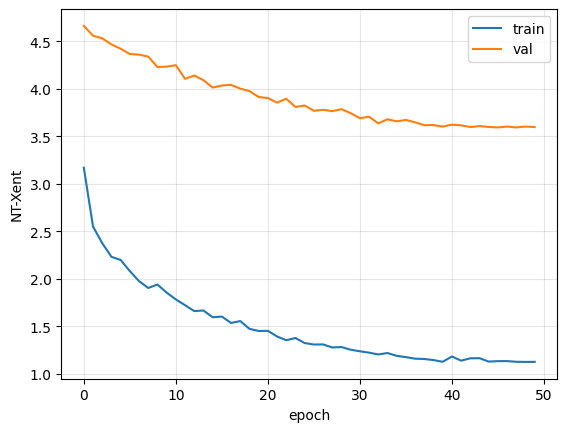

In [3]:
import json
hist = json.load(open("../results/metrics/ssl_training.json"))
import matplotlib.pyplot as plt
plt.plot(hist["history"]["train_loss"], label="train")
plt.plot(hist["history"]["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("NT-Xent"); plt.legend(); plt.grid(alpha=.3)